In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader, random_split
import os
import numpy as np
from sklearn.metrics import classification_report
from datetime import datetime

# ==============================================
# 1. SETUP AND CONFIGURATION
# ==============================================

# Проверка доступности GPU и вывод информации
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*50}")
print(f"{'TRAINING SETUP':^50}")
print(f"{'='*50}")
print(f"Device in use: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
print(f"PyTorch Version: {torch.__version__}")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# ==============================================
# 2. DATA PREPARATION
# ==============================================

data_dir = 'dataset'
print(f"\n{'='*50}")
print(f"{'DATA PREPARATION':^50}")
print(f"{'='*50}")

# Трансформаций для изображений
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

print("Loading dataset...")
full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms['train'])

# Разделение на тренировочную и валидационную выборки
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset.dataset.transform = data_transforms['train']
val_dataset.dataset.transform = data_transforms['val']

# Создание DataLoader
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Получение информации о классах
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"\nDataset Information:")
print(f"- Total images: {len(full_dataset)}")
print(f"- Training images: {len(train_dataset)}")
print(f"- Validation images: {len(val_dataset)}")
print(f"- Number of classes: {num_classes}")
print(f"- Class names: {class_names}")

# ==============================================
# 3. MODEL INITIALIZATION
# ==============================================

print(f"\n{'='*50}")
print(f"{'MODEL INITIALIZATION':^50}")
print(f"{'='*50}")

print("Initializing ResNet18 model...")
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features

# Замена последнего слоя
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

# Вывод информации о модели
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Architecture:")
print(model)
print(f"\nModel Parameters:")
print(f"- Total parameters: {total_params:,}")
print(f"- Trainable parameters: {trainable_params:,}")
print(f"- Last layer features: {num_ftrs} -> {num_classes}")

# ==============================================
# 4. TRAINING SETUP
# ==============================================

# Определение функции потерь и оптимизатора
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

print(f"\n{'='*50}")
print(f"{'TRAINING CONFIGURATION':^50}")
print(f"{'='*50}")
print(f"Loss Function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning Rate: {optimizer.param_groups[0]['lr']}")
print(f"Momentum: {optimizer.param_groups[0]['momentum']}")
print(f"Batch Size: {batch_size}")

# ==============================================
# 5. TRAINING LOOP
# ==============================================

def train_model(model, criterion, optimizer, num_epochs=10):
    print(f"\n{'='*50}")
    print(f"{'STARTING TRAINING':^50}")
    print(f"{'='*50}")
    print(f"Training for {num_epochs} epochs...\n")
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            total_samples = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                batch_size = inputs.size(0)
                total_samples += batch_size

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * batch_size
                running_corrects += torch.sum(preds == labels.data)

                # Прогресс внутри эпохи
                if phase == 'train':
                    print(f"\r{phase}: [{total_samples}/{len(dataloader.dataset)}] "
                          f"Loss: {loss.item():.4f} | Acc: {torch.sum(preds == labels.data).item()/batch_size:.4f}", end="")

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            if phase == 'val':
                print(f"\r{phase:<5} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | "
                      f"Correct: {running_corrects}/{len(dataloader.dataset)}")
            else:
                print(f"\r{phase:<5} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | "
                      f"Correct: {running_corrects}/{len(dataloader.dataset)}")

    return model

# Запуск обучения
model = train_model(model, criterion, optimizer, num_epochs=10)

# ==============================================
# 6. MODEL EVALUATION
# ==============================================

def evaluate_model(model, dataloader, class_names):
    print(f"\n{'='*50}")
    print(f"{'MODEL EVALUATION':^50}")
    print(f"{'='*50}")
    
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Вывод отчета по классификации
    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        digits=4
    ))

# Оценка модели
evaluate_model(model, val_loader, class_names)

# ==============================================
# 7. MODEL SAVING
# ==============================================

print(f"\n{'='*50}")
print(f"{'SAVING MODEL':^50}")
print(f"{'='*50}")
torch.save(model.state_dict(), 'image_classifier.pth')
print(f"Model successfully saved to 'image_classifier.pth'")
print(f"\nTraining completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'='*50}")


                  TRAINING SETUP                  
Device in use: cpu
PyTorch Version: 2.7.0+cpu
Start Time: 2025-06-01 21:25:57

                 DATA PREPARATION                 
Loading dataset...

Dataset Information:
- Total images: 3092
- Training images: 2473
- Validation images: 619
- Number of classes: 8
- Class names: ['Building', 'City', 'Desert', 'Factory', 'Forest', 'Mountains', 'Open_waters', 'Road']

               MODEL INITIALIZATION               
Initializing ResNet18 model...

Model Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-0

C:\Users\KOVALEV\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\KOVALEV\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



               IMAGE CLASSIFICATION               
Start Time: 2025-06-01 22:09:22
Available classes (8): Building, City, Desert, Factory, Forest, Mountains, Open_waters, Road

                SYSTEM INFORMATION                
Using device: cpu
PyTorch Version: 2.7.0+cpu

                  MODEL LOADING                   
Initializing ResNet18 model...
Loading model weights from: image_classifier.pth

Model successfully loaded to cpu!
- Total parameters: 11,180,616
- Input size: 224x224
- Output classes: 8

              READY FOR PREDICTIONS               
Enter path to an image or 'quit' to exit



Image path >  ./images/buildin.jpg



Processing new image at: 22:09:50

                 IMAGE PROCESSING                 
Processing image: ./images/buildin.jpg
- Original image mode: RGB
- Original image size: (1280, 853)
- Applied grayscale conversion for compatibility
- Image transformed and sent to device

Running prediction...

Saved visualization to: prediction_result.jpg


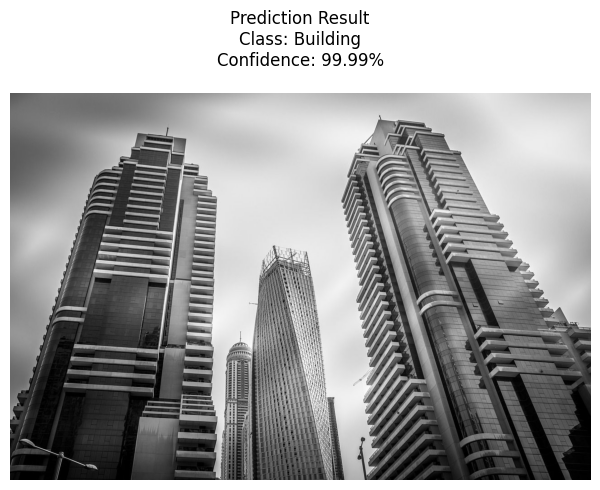


                PREDICTION RESULTS                

Class           Probability     Status    
----------------------------------------
Building        0.9999 (99.99%)     ← PREDICTED
City            0.0000 (0.00%)                
Desert          0.0000 (0.00%)                
Factory         0.0000 (0.00%)                
Forest          0.0000 (0.00%)                
Mountains       0.0000 (0.00%)                
Open_waters     0.0000 (0.00%)                
Road            0.0000 (0.00%)                

========================= FINAL RESULT =========================
Predicted class:     Building
Confidence:          99.99%
Timestamp:           2025-06-01 22:09:50



Image path >  ./images/city.jpg



Processing new image at: 22:10:09

                 IMAGE PROCESSING                 
Processing image: ./images/city.jpg
- Original image mode: RGB
- Original image size: (1778, 1080)
- Applied grayscale conversion for compatibility
- Image transformed and sent to device

Running prediction...

Saved visualization to: prediction_result.jpg


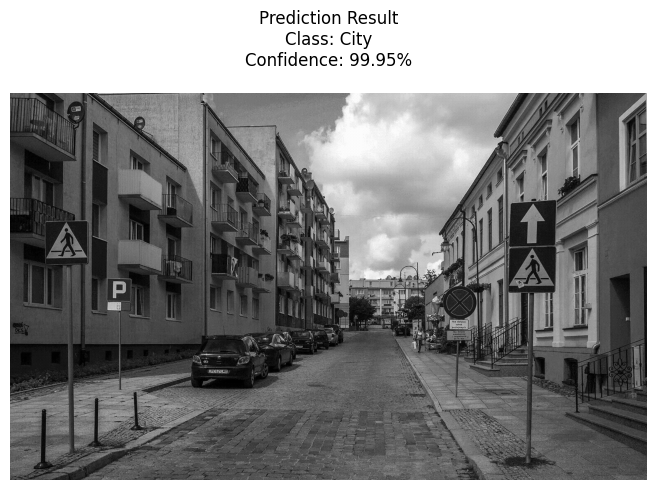


                PREDICTION RESULTS                

Class           Probability     Status    
----------------------------------------
Building        0.0000 (0.00%)                
City            0.9995 (99.95%)     ← PREDICTED
Desert          0.0000 (0.00%)                
Factory         0.0003 (0.03%)                
Forest          0.0000 (0.00%)                
Mountains       0.0000 (0.00%)                
Open_waters     0.0000 (0.00%)                
Road            0.0002 (0.02%)                

========================= FINAL RESULT =========================
Predicted class:     City
Confidence:          99.95%
Timestamp:           2025-06-01 22:10:10



Image path >  ./dataset/Desert/226.jpg



Processing new image at: 22:10:52

                 IMAGE PROCESSING                 
Processing image: ./dataset/Desert/226.jpg
- Original image mode: RGB
- Original image size: (256, 256)
- Applied grayscale conversion for compatibility
- Image transformed and sent to device

Running prediction...

Saved visualization to: prediction_result.jpg


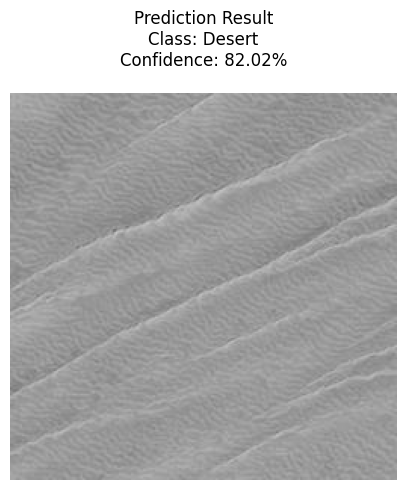


                PREDICTION RESULTS                

Class           Probability     Status    
----------------------------------------
Building        0.0241 (2.41%)                
City            0.0028 (0.28%)                
Desert          0.8202 (82.02%)     ← PREDICTED
Factory         0.0082 (0.82%)                
Forest          0.0076 (0.76%)                
Mountains       0.0707 (7.07%)                
Open_waters     0.0592 (5.92%)                
Road            0.0071 (0.71%)                

========================= FINAL RESULT =========================
Predicted class:     Desert
Confidence:          82.02%
Timestamp:           2025-06-01 22:10:52



Image path >  ./images/factory.jpg



Processing new image at: 22:11:24

                 IMAGE PROCESSING                 
Processing image: ./images/factory.jpg
- Original image mode: RGB
- Original image size: (830, 601)
- Applied grayscale conversion for compatibility
- Image transformed and sent to device

Running prediction...

Saved visualization to: prediction_result.jpg


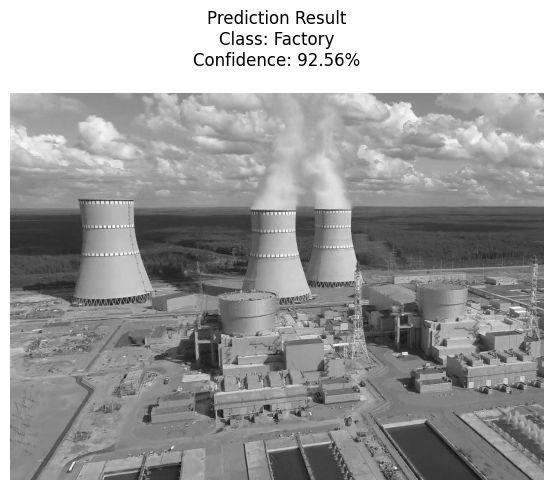


                PREDICTION RESULTS                

Class           Probability     Status    
----------------------------------------
Building        0.0233 (2.33%)                
City            0.0001 (0.01%)                
Desert          0.0001 (0.01%)                
Factory         0.9256 (92.56%)     ← PREDICTED
Forest          0.0001 (0.01%)                
Mountains       0.0007 (0.07%)                
Open_waters     0.0347 (3.47%)                
Road            0.0153 (1.53%)                

========================= FINAL RESULT =========================
Predicted class:     Factory
Confidence:          92.56%
Timestamp:           2025-06-01 22:11:24



Image path >  ./images/forest.jpg



Processing new image at: 22:11:33

                 IMAGE PROCESSING                 
Processing image: ./images/forest.jpg
- Original image mode: RGB
- Original image size: (1000, 750)
- Applied grayscale conversion for compatibility
- Image transformed and sent to device

Running prediction...

Saved visualization to: prediction_result.jpg


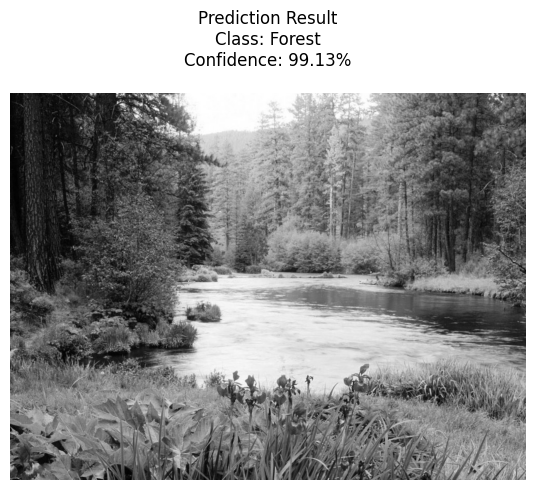


                PREDICTION RESULTS                

Class           Probability     Status    
----------------------------------------
Building        0.0002 (0.02%)                
City            0.0005 (0.05%)                
Desert          0.0005 (0.05%)                
Factory         0.0005 (0.05%)                
Forest          0.9913 (99.13%)     ← PREDICTED
Mountains       0.0003 (0.03%)                
Open_waters     0.0063 (0.63%)                
Road            0.0005 (0.05%)                

========================= FINAL RESULT =========================
Predicted class:     Forest
Confidence:          99.13%
Timestamp:           2025-06-01 22:11:33



Image path >  ./images/mountain.jpg



Processing new image at: 22:13:17

                 IMAGE PROCESSING                 
Processing image: ./images/mountain.jpg
- Original image mode: RGB
- Original image size: (1200, 900)
- Applied grayscale conversion for compatibility
- Image transformed and sent to device

Running prediction...

Saved visualization to: prediction_result.jpg


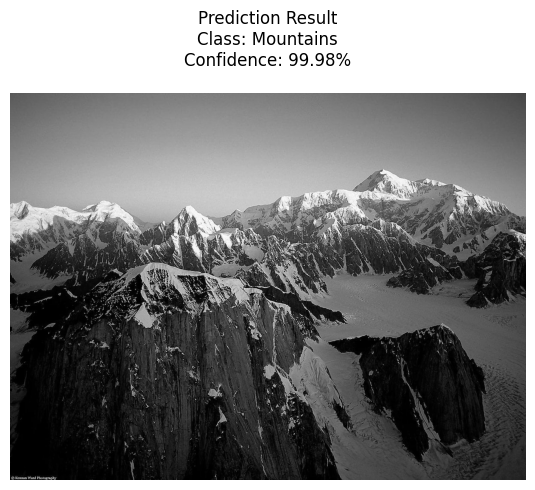


                PREDICTION RESULTS                

Class           Probability     Status    
----------------------------------------
Building        0.0000 (0.00%)                
City            0.0001 (0.01%)                
Desert          0.0000 (0.00%)                
Factory         0.0000 (0.00%)                
Forest          0.0000 (0.00%)                
Mountains       0.9998 (99.98%)     ← PREDICTED
Open_waters     0.0000 (0.00%)                
Road            0.0000 (0.00%)                

========================= FINAL RESULT =========================
Predicted class:     Mountains
Confidence:          99.98%
Timestamp:           2025-06-01 22:13:17



Image path >  ./images/water.jpg



Processing new image at: 22:13:25

                 IMAGE PROCESSING                 
Processing image: ./images/water.jpg
- Original image mode: RGB
- Original image size: (2560, 1920)
- Applied grayscale conversion for compatibility
- Image transformed and sent to device

Running prediction...

Saved visualization to: prediction_result.jpg


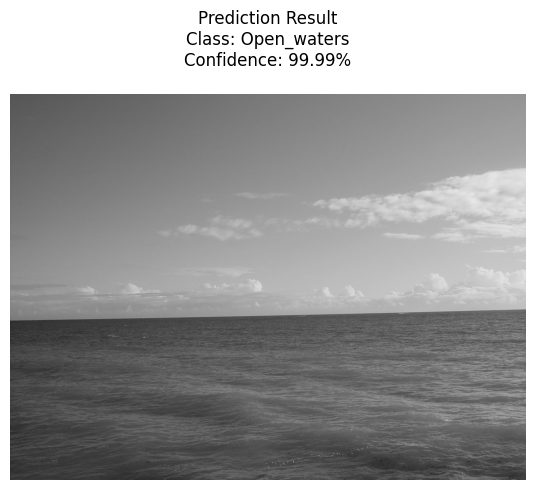


                PREDICTION RESULTS                

Class           Probability     Status    
----------------------------------------
Building        0.0000 (0.00%)                
City            0.0000 (0.00%)                
Desert          0.0000 (0.00%)                
Factory         0.0000 (0.00%)                
Forest          0.0000 (0.00%)                
Mountains       0.0000 (0.00%)                
Open_waters     0.9999 (99.99%)     ← PREDICTED
Road            0.0001 (0.01%)                

========================= FINAL RESULT =========================
Predicted class:     Open_waters
Confidence:          99.99%
Timestamp:           2025-06-01 22:13:26



Image path >  ./images/road.jpg



Processing new image at: 22:13:37

                 IMAGE PROCESSING                 
Processing image: ./images/road.jpg
- Original image mode: RGB
- Original image size: (1920, 1080)
- Applied grayscale conversion for compatibility
- Image transformed and sent to device

Running prediction...

Saved visualization to: prediction_result.jpg


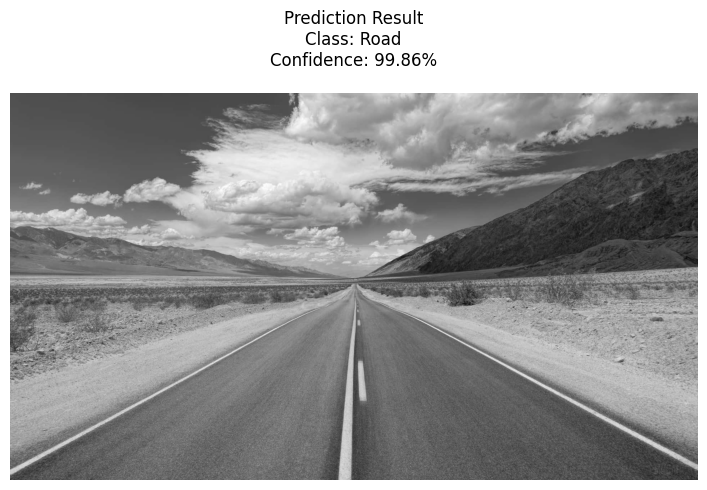


                PREDICTION RESULTS                

Class           Probability     Status    
----------------------------------------
Building        0.0000 (0.00%)                
City            0.0003 (0.03%)                
Desert          0.0000 (0.00%)                
Factory         0.0003 (0.03%)                
Forest          0.0000 (0.00%)                
Mountains       0.0005 (0.05%)                
Open_waters     0.0002 (0.02%)                
Road            0.9986 (99.86%)     ← PREDICTED

========================= FINAL RESULT =========================
Predicted class:     Road
Confidence:          99.86%
Timestamp:           2025-06-01 22:13:38



Image path >  quit



Exiting application...

Application closed at: 2025-06-01 22:16:00


In [13]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import json
from datetime import datetime

# ==============================================
# 1. CONFIGURATION AND SETUP
# ==============================================

# Определение классов
class_names = ['Building', 'City', 'Desert', 'Factory', 'Forest', 
               'Mountains', 'Open_waters', 'Road']
num_classes = len(class_names)

print(f"\n{'='*50}")
print(f"{'IMAGE CLASSIFICATION':^50}")
print(f"{'='*50}")
print(f"Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Available classes ({num_classes}): {', '.join(class_names)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*50}")
print(f"{'SYSTEM INFORMATION':^50}")
print(f"{'='*50}")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
print(f"PyTorch Version: {torch.__version__}")

# ==============================================
# 2. MODEL LOADING
# ==============================================

def load_model(model_path, num_classes):
    print(f"\n{'='*50}")
    print(f"{'MODEL LOADING':^50}")
    print(f"{'='*50}")
    print("Initializing ResNet18 model...")
    
    model = models.resnet18(pretrained=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    # Загрузка весов
    print(f"Loading model weights from: {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    
    # Информация о модели
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nModel successfully loaded to {device}!")
    print(f"- Total parameters: {total_params:,}")
    print(f"- Input size: 224x224")
    print(f"- Output classes: {num_classes}")
    
    return model

# ==============================================
# 3. IMAGE PREDICTION
# ==============================================

def predict_image(image_path, model, class_names):
    print(f"\n{'='*50}")
    print(f"{'IMAGE PROCESSING':^50}")
    print(f"{'='*50}")
    print(f"Processing image: {image_path}")
    
    # Трансформации изображения
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Загрузка и преобразование изображения
    try:
        image = Image.open(image_path)
        print(f"- Original image mode: {image.mode}")
        print(f"- Original image size: {image.size}")
        
        if image.mode != 'RGB':
            print("- Converting image to RGB...")
            image = image.convert('RGB')
            
        # Добавляем преобразование в черно-белое
        image = image.convert('L').convert('RGB')
        print("- Applied grayscale conversion for compatibility")

        image_tensor = transform(image).unsqueeze(0).to(device)
        print("- Image transformed and sent to device")
    except Exception as e:
        print(f"\n{'!'*20} ERROR {'!'*20}")
        print(f"Failed to process image: {e}")
        raise

    # Предсказание
    print("\nRunning prediction...")
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted = torch.max(outputs, 1)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)

    predicted_idx = predicted.item()
    predicted_class = class_names[predicted_idx]
    confidence = probabilities[predicted_idx].item()

    # Визуализация
    plt.figure(figsize=(10, 5))
    plt.imshow(image)
    plt.title(f'Prediction Result\nClass: {predicted_class}\nConfidence: {confidence:.2%}', 
              fontsize=12, pad=20)
    plt.axis('off')
    plt.tight_layout()
    
    result_path = "prediction_result.jpg"
    plt.savefig(result_path, bbox_inches='tight', pad_inches=0.1)
    print(f"\nSaved visualization to: {result_path}")
    plt.show()

    # Вывод всех вероятностей
    print(f"\n{'='*50}")
    print(f"{'PREDICTION RESULTS':^50}")
    print(f"{'='*50}")
    print(f"\n{'Class':<15} {'Probability':<15} {'Status':<10}")
    print("-" * 40)
    
    for i, class_name in enumerate(class_names):
        prob = probabilities[i].item()
        status = "← PREDICTED" if i == predicted_idx else ""
        print(f"{class_name:<15} {prob:.4f} ({prob:.2%}) {status:>15}")

    return predicted_class, confidence

# ==============================================
# 4. MAIN APPLICATION
# ==============================================

def main():
    # Загрузка модели
    model = load_model('image_classifier.pth', num_classes=num_classes)

    print(f"\n{'='*50}")
    print(f"{'READY FOR PREDICTIONS':^50}")
    print(f"{'='*50}")
    print("Enter path to an image or 'quit' to exit\n")

    # Основной цикл
    while True:
        try:
            image_path = input("Image path > ").strip()
            if image_path.lower() in ['quit', 'exit', 'q']:
                print("\nExiting application...")
                break

            print(f"\n{'='*50}")
            print(f"Processing new image at: {datetime.now().strftime('%H:%M:%S')}")
            
            predicted_class, confidence = predict_image(image_path, model, class_names)
            
            print(f"\n{'='*25} FINAL RESULT {'='*25}")
            print(f"{'Predicted class:':<20} {predicted_class}")
            print(f"{'Confidence:':<20} {confidence:.2%}")
            print(f"{'Timestamp:':<20} {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"{'='*62}\n")

        except Exception as e:
            print(f"\n{'!'*20} ERROR {'!'*20}")
            print(f"An error occurred: {e}")
            print("Please try another image or check the file path\n")

if __name__ == "__main__":
    main()
    print(f"\nApplication closed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")